# Weighted Soft-Voting Ensemble (XGBoost + LightGBM)

This notebook trains individual pre-tuned **XGBoost** and **LightGBM** models on Speech Emotion Recognition features, evaluates their performance, and combines them using a **weighted soft-voting ensemble** to maximize classification F1-score and robustness.


In [13]:
# ============================================================
# Library Imports
# ============================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Model Configuration & Pre-tuned Parameters

We define the best hyperparameters found from hyperparameter optimization, and set up the validation F1 scores to be used as weighting factors for the soft-voting ensemble.


In [14]:
# ============================================================
# Global Constants and Pre-tuned Model Hyperparameters
# ============================================================
RANDOM_STATE = 42

# Best hyperparameters tuned via Optuna in advanced_ml_models.ipynb
XGB_PARAMS = {
    'n_estimators': 468,
    'max_depth': 10,
    'learning_rate': 0.17549140891728818,
    'subsample': 0.9690394070981359,
    'colsample_bytree': 0.7725519831966194,
    'gamma': 1.0492767129301485e-08,
}

LGB_PARAMS = {
    'n_estimators': 499,
    'max_depth': 11,
    'num_leaves': 67,
    'learning_rate': 0.24625126683753454,
    'subsample': 0.6909971314141472,
    'colsample_bytree': 0.7554088091076056,
}

# Validation F1 scores to serve as weights in soft-voting ensemble
XGB_VAL_F1 = 0.8334582426563992
LGB_VAL_F1 = 0.842069322599305


## Load CSV Dataset

We resolve paths and load the unified audio emotion features dataset (`all_emotions.csv`).


In [15]:
# ============================================================
# Dataset Loading
# ============================================================
# Resolve dataset path (prefer dataset/all_emotions.csv, fall back to root)
_base = os.getcwd()
_project_root = os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
ALL_EMOTIONS_CSV = os.path.normpath(os.path.join(_project_root, "dataset", "all_emotions.csv"))

if not os.path.isfile(ALL_EMOTIONS_CSV):
    fallback_csv = os.path.normpath(os.path.join(_project_root, "all_emotions.csv"))
    if os.path.isfile(fallback_csv):
        ALL_EMOTIONS_CSV = fallback_csv

print(f"Loading dataset from: {ALL_EMOTIONS_CSV}")
df = pd.read_csv(ALL_EMOTIONS_CSV)
print(f"Raw shape: {df.shape}")


Loading dataset from: c:\Users\User\Downloads\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\all_emotions.csv
Raw shape: (54485, 49)


## Target Cleaning & Feature Selection

We filter out rows with missing labels and select the **26 highly-informative features** selected based on Random Forest feature importances. Missing feature values are handled using median imputation.


In [16]:
# ============================================================
# Target Cleaning and Feature Imputation
# ============================================================
TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

# Clean missing label rows
df_cleaned = df.dropna(subset=[TARGET_COL]).copy()
df_cleaned = df_cleaned[df_cleaned[TARGET_COL].astype(str).str.strip().str.lower() != "nan"]

# 26 features pruned via Random Forest feature importances
FEATURE_COLS = [
    "F0_mean", "F0_std", "F0_range",
    "Energy_ mean", "Energy_ std",
    "ZCR_mean", "ZCR_std",
    "Spectral_centroid_mean", "Spectral_centroid_std", "Spectral_flux_mean",
    "MFCC_C0_mean", "MFCC_C1_mean", "MFCC_C2_mean", "MFCC_C3_mean",
    "MFCC_C5_mean", "MFCC_C7_mean", "MFCC_C10_mean",
    "MFCC_C0_std", "MFCC_C1_std", "MFCC_C2_std", "MFCC_C3_std",
    "MFCC_C5_std", "MFCC_C7_std",
    "Delta_MFCC_C0_std", "Delta_MFCC_C2_std", "Delta_MFCC_C3_std",
]

# Impute features with median
for col in FEATURE_COLS:
    s = pd.to_numeric(df_cleaned[col], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    df_cleaned[col] = s.fillna(med)

X = df_cleaned[FEATURE_COLS].copy()
y_label = df_cleaned[TARGET_COL].astype(str).str.strip()

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)

print(f"Cleaned X shape: {X.shape}")
print(f"Classes: {le.classes_}")


Cleaned X shape: (54485, 26)
Classes: ['anger' 'disgust' 'fear' 'happy' 'neutral' 'sad']


## Stratified Splitting and Feature Scaling

We split the dataset into stratified training (80%) and testing (20%) sets, and scale them using standard scaling.


In [17]:
# ============================================================
# Stratified Train-Test Split & Scaling
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}")


Train shape: (43588, 26) | Test shape: (10897, 26)


## Model Training

We instantiate XGBoost and LightGBM using the pre-tuned parameters and fit them on the full scaled training set.


In [18]:
# ============================================================
# Final Models Training
# ============================================================
xgb_model = xgb.XGBClassifier(
    **XGB_PARAMS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=len(le.classes_),
)

lgb_model = lgb.LGBMClassifier(
    **LGB_PARAMS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    objective='multiclass',
    num_class=len(le.classes_),
)

print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("Training LightGBM...")
lgb_model.fit(X_train_scaled, y_train)
print("Training complete.")


Training XGBoost...
Training LightGBM...
Training complete.


## Single Model Performance Evaluation

We run predictions on the test set using both models independently and output their precision, recall, F1, and Cohen Kappa metrics.


In [19]:
# ============================================================
# Individual Model Performance Evaluation
# ============================================================
xgb_pred = xgb_model.predict(X_test_scaled)
lgb_pred = lgb_model.predict(X_test_scaled)

xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")
xgb_kappa = cohen_kappa_score(y_test, xgb_pred)

lgb_f1 = f1_score(y_test, lgb_pred, average="weighted")
lgb_kappa = cohen_kappa_score(y_test, lgb_pred)

print("\n=== XGBoost Test Metrics ===")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))
print(f"XGBoost weighted F1: {xgb_f1:.4f} | Cohen Kappa: {xgb_kappa:.4f}")

print("\n=== LightGBM Test Metrics ===")
print(classification_report(y_test, lgb_pred, target_names=le.classes_))
print(f"LightGBM weighted F1: {lgb_f1:.4f} | Cohen Kappa: {lgb_kappa:.4f}")



=== XGBoost Test Metrics ===
              precision    recall  f1-score   support

       anger       0.95      0.90      0.92      1863
     disgust       0.83      0.85      0.84      1863
        fear       0.84      0.83      0.83      1863
       happy       0.81      0.83      0.82      1863
     neutral       0.80      0.83      0.81      1583
         sad       0.87      0.85      0.86      1862

    accuracy                           0.85     10897
   macro avg       0.85      0.85      0.85     10897
weighted avg       0.85      0.85      0.85     10897

XGBoost weighted F1: 0.8495 | Cohen Kappa: 0.8188

=== LightGBM Test Metrics ===
              precision    recall  f1-score   support

       anger       0.94      0.90      0.92      1863
     disgust       0.83      0.85      0.84      1863
        fear       0.85      0.83      0.84      1863
       happy       0.82      0.83      0.82      1863
     neutral       0.79      0.84      0.81      1583
         sad       0.

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Weighted Soft-Voting Ensemble

We extract class probability predictions (`predict_proba`) from both models and perform a weighted average of probabilities using validation F1-scores as weights:

$$\hat{p} = \frac{w_{\text{xgb}} \cdot p_{\text{xgb}} + w_{\text{lgb}} \cdot p_{\text{lgb}}}{w_{\text{xgb}} + w_{\text{lgb}}}$$

The class with the highest ensemble probability is chosen as the final prediction.


In [20]:
# ============================================================
# Weighted Soft-Voting Ensemble Prediction
# ============================================================
# Compute class probability predictions
xgb_proba = xgb_model.predict_proba(X_test_scaled)
lgb_proba = lgb_model.predict_proba(X_test_scaled)

# Weighted average of probability values
ensemble_weights = np.array([XGB_VAL_F1, LGB_VAL_F1], dtype=float)
ensemble_proba = (
    ensemble_weights[0] * xgb_proba + ensemble_weights[1] * lgb_proba
) / ensemble_weights.sum()
ensemble_pred = np.argmax(ensemble_proba, axis=1)

ensemble_f1 = f1_score(y_test, ensemble_pred, average="weighted")
ensemble_kappa = cohen_kappa_score(y_test, ensemble_pred)
ensemble_report = classification_report(y_test, ensemble_pred, target_names=le.classes_, output_dict=True)

print("\n=== Weighted Ensemble (XGBoost + LightGBM) ===")
print(classification_report(y_test, ensemble_pred, target_names=le.classes_))
print(f"Ensemble weighted F1: {ensemble_f1:.4f} | Cohen Kappa: {ensemble_kappa:.4f}")



=== Weighted Ensemble (XGBoost + LightGBM) ===
              precision    recall  f1-score   support

       anger       0.94      0.90      0.92      1863
     disgust       0.83      0.85      0.84      1863
        fear       0.85      0.84      0.85      1863
       happy       0.82      0.83      0.82      1863
     neutral       0.80      0.84      0.81      1583
         sad       0.88      0.86      0.87      1862

    accuracy                           0.85     10897
   macro avg       0.85      0.85      0.85     10897
weighted avg       0.85      0.85      0.85     10897

Ensemble weighted F1: 0.8536 | Cohen Kappa: 0.8236


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Visualizing Performance: Confusion Matrices

We plot confusion matrices side-by-side to visually inspect true vs predicted classes for XGBoost, LightGBM, and the Ensemble.


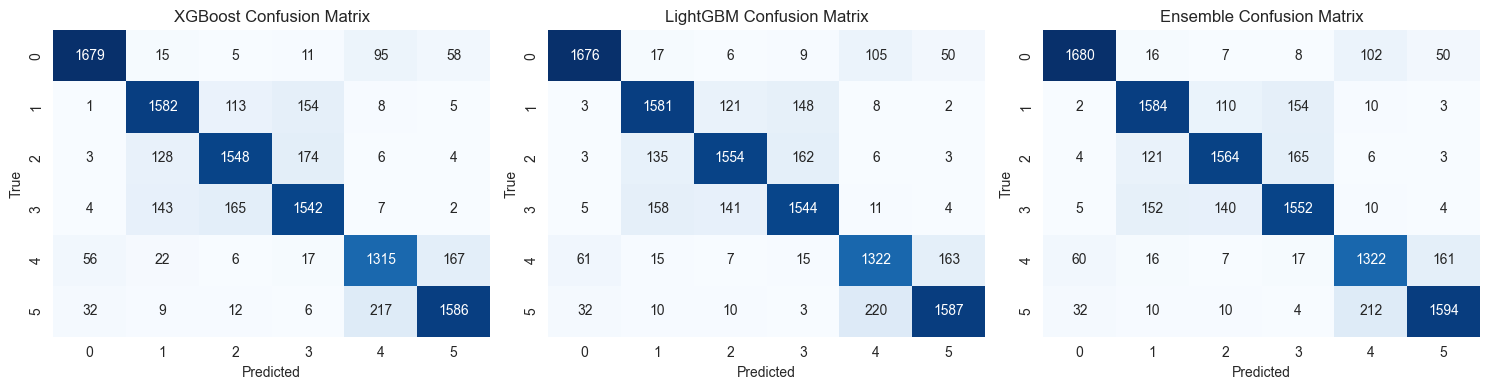

In [21]:
# ============================================================
# Performance Visualizations: Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (pred, title) in enumerate([
    (xgb_pred, "XGBoost"),
    (lgb_pred, "LightGBM"),
    (ensemble_pred, "Ensemble"),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{title} Confusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
plt.show()


## Performance Comparison: F1 and Cohen Kappa

We compare the test performance (weighted F1-score and Cohen Kappa) of individual models vs the weighted ensemble.


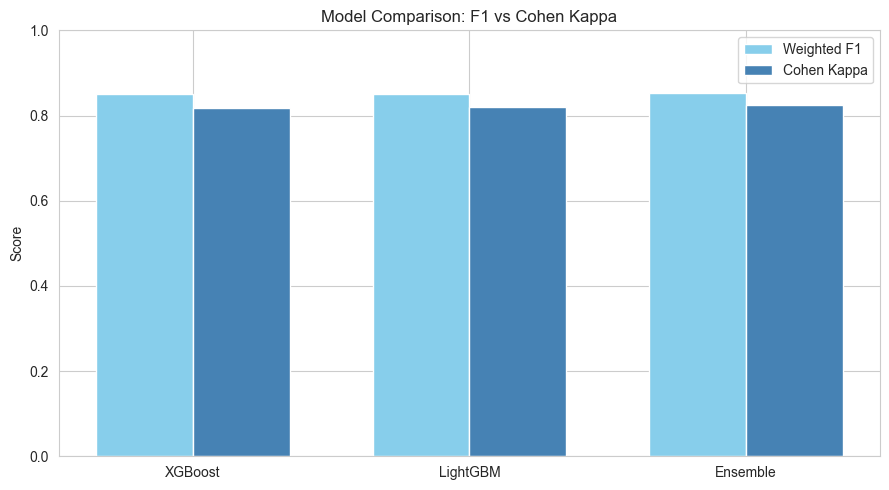

In [22]:
# ============================================================
# Model Comparison Plot (F1-Score vs Cohen Kappa)
# ============================================================
models = ["XGBoost", "LightGBM", "Ensemble"]
f1_scores = [xgb_f1, lgb_f1, ensemble_f1]
kappas = [xgb_kappa, lgb_kappa, ensemble_kappa]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, f1_scores, width, label="Weighted F1", color="skyblue")
plt.bar(x + width / 2, kappas, width, label="Cohen Kappa", color="steelblue")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison: F1 vs Cohen Kappa")
plt.legend()
plt.tight_layout()
plt.show()


## Per-Class F1-Scores

We plot a bar chart of the F1-scores of each emotion class to see which emotions are easiest or hardest to classify.


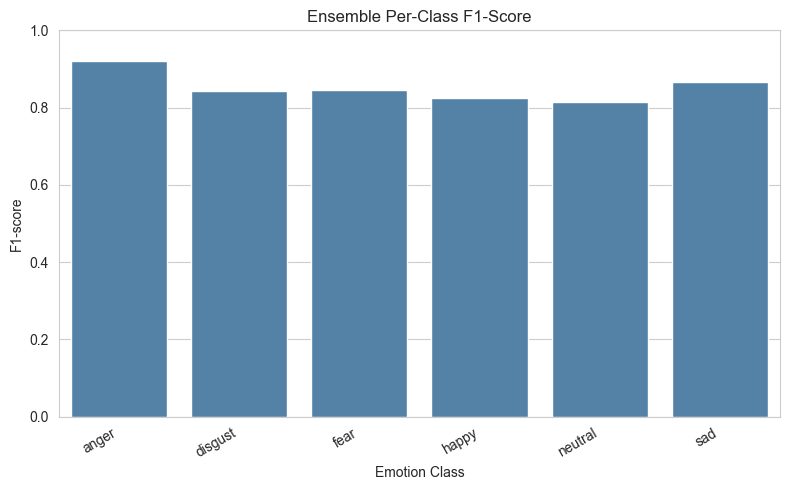

In [23]:
# ============================================================
# Ensemble Per-Class F1-Scores
# ============================================================
class_f1 = [ensemble_report[label]["f1-score"] for label in le.classes_]

plt.figure(figsize=(8, 5))
sns.barplot(x=list(le.classes_), y=class_f1, color="steelblue")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Emotion Class")
plt.title("Ensemble Per-Class F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Summary

We print a final text table summarizing all model metrics.


In [24]:
# ============================================================
# Final Ensemble Evaluation Summary
# ============================================================
print("\n=== Model Metrics Summary ===")
print(f"XGBoost  | Weighted F1: {xgb_f1:.4f} | Cohen's Kappa: {xgb_kappa:.4f}")
print(f"LightGBM | Weighted F1: {lgb_f1:.4f} | Cohen's Kappa: {lgb_kappa:.4f}")
print(f"Ensemble | Weighted F1: {ensemble_f1:.4f} | Cohen's Kappa: {ensemble_kappa:.4f}")



=== Model Metrics Summary ===
XGBoost  | Weighted F1: 0.8495 | Cohen's Kappa: 0.8188
LightGBM | Weighted F1: 0.8506 | Cohen's Kappa: 0.8201
Ensemble | Weighted F1: 0.8536 | Cohen's Kappa: 0.8236
